## <span style="color:blue"> Lezione 6 </span>



In [1]:

import matplotlib.pyplot as plt
import numpy as np

parent_folder="l_06_es_1/RESULTS/"

### <span style="color:DodgerBlue"> Esercizio 6.1  </span>



L'hamiltoniana del modello di Ising unidimensionale è data dalla seguente espressione (in unità di misura tali che $\mu_B=1$ e $k_B=1$ e assunte condizioni periodiche al contorno $s_{N+1}=s_1$):$$ H (s_1,\dots s_{N})= 
-J\sum_{i=1}^{N} s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^{N} (s_i + s_{i+1}) $$

dove ciascuno spin $s_i$ può valere o $1$ o $-1$. Si considera $J>0$ (sistema ferromagnetico).
Nell'ensemble canonico, la probabilità di trovare una specifica configurazione $\{s_i\}=\{s_1,\dots,s_{N}\}$ sarà: $$
    p(\{s_i\})= \frac{\exp(-\beta H(\{s_i\}))}{Z}.$$ 

dove $\beta=1/(k_B T)$. $$Z=\sum_{\{ s_i \}} \exp \left( -\beta H(\{s_i\}) \right),$$ 
dove la somma corre su tutte le possibili configurazioni $\{s_i\}$,
è detta _funzione di partizione_ e, nel caso specifico, è calcolabile esattamente. 
Data una funzione $F(s_1,\dots, s_{N})$ il suo valore medio è: $$ \langle F \rangle = \sum_{\{s_i\}} \frac{\exp(-\beta H(\{s_i\}))}{Z} F(\{s_i\}) $$
che dipende dal numero di spin $N$,dalla temperatura $T$ e dal campo $h$. (Il parametro $J$ si considera fissato).



Poichè $Z$ è calcolabile analiticamente, si ha una forma chiusa per l'energia libera di Helmhotz $A(T,N,h)=- T k_B \log(Z)$. Il che implica una forma chiusa per le seguenti quantità: 

1. Energia interna: $U(N,T,h) = \langle H \rangle_{h}= - \frac{\partial \log(Z)}{\partial \beta}$

2. Calore specifico (a volume costante): $C(N,T,h) = \frac{1}{N}k_B \beta^2 (\langle H^2 \rangle_{h}-\langle H \rangle_{h}^2)= \frac{1}{N}\frac{\partial U}{\partial T}$ 

3. Magnetizzazione: $M(N,T,h)= \langle \sum_{i=1}^{N}s_i \rangle_{h}= - \frac{\partial A}{\partial h}$

4. Suscettibilità $\chi(N,T,h) = \beta \left( \langle (\sum_{i=1}^{N}s_i)^2 \rangle_{h}-\langle \sum_{i=1}^{N}s_i \rangle_{h}^2\right)=  \frac{\partial M}{\partial h}  $



le cui formule sono implementate nella cella sottostante. 


Con $h=0$ verranno calcolate $U(N,T,h=0)/N$, $C(N,T,h=0)$ e $\chi(N,T,h=0)$, ma non la magnetizzazione, che per $h=0$ è nulla. Quest'ultima verrà calcolata con $h=0.02$. Si nota che, per $h=0$, l'espressione per la suscettibilità si semplifica: $\chi(N,T,h) =\beta  \langle (\sum_{i=1}^{N}s_i)^2 \rangle _{h=0} $


I parametri sono stati fissati a $J=1$, $N=50$ spin. 


In [2]:
J = 1.0 #termine pairing
Ns = 50 #numero spin

#Energia totale(h=0)

def te(T):
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        return -J*( th + ch*thN )/( 1 + thN )

#Calore specifico (h=0)
def heat(T):
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        beta=1/T
        return ((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)


#Magnetizzazione

def M(T): 
        h=0.02 #external field
        b = 1/T

        l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        Z = l1**Ns + l2**Ns
        M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
                + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
        return M
#Suscettibilità (h=0)

def X(T):
        beta=1/T
        th = np.tanh(J/T)
        thN= th**Ns
        return beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

Il modello di Ising può essere simulato, e le quantità elencate sopra possono essere trovate come medie di ensamble.
 
Verranno effettuate simulazioni con $T$ nel range $[0.5,2.0]$ a passi di $0.1$. I risultati saranno poi messi a confronto con la soluzione analitica. 

Nella cella sottostante sono riportate le costruzioni degli array di temperature: `T_values` con passo $0.1$ contiene le temperature per cui sono state effettuate le simulazioni, mentre `T`, con passo molto più fine, serve per il plot delle funzioni teoriche.


In [3]:
T_min=0.5
T_max=2.0
delta=0.1

R=int((T_max-T_min)/delta) #numero punti per grafico simulazioni
T_values=np.linspace(T_min,T_max,R+1)
points=10000
T = np.linspace(T_min-0.1,T_max+0.1,num=points)



Il sampling della distribuzione  viene fatto con due metodi, che vengono messi a confronto: Metropolis e Gibbs.

### Algoritmo di Metropolis

L'algoritmo di Metropolis funziona nel modo seguente: 

1. Si applica la mossa dettata dalla matrice di transizione $T(y|x)$.
2. Si calcola $p(y)$.
3. Si accetta la mossa con probabilità $$A(y|x)=\min \left[1,\frac{T(x|y)p(y)}{T(y |x)p(x)}\right].$$


Nel caso specifico, partendo da una configurazione $\{s_i\}$:

- La proposta di mossa corrisponde a scegliere randomicamente uno spin $s_k$ e girarlo : $T(\{s_1,\dots,-s_k,\dots\}|\{s_1,\dots,s_k,\dots\})$. Con $\{s_1,\dots,s_k,\dots\}$ si indica la configurazione $\{s_i\}$ in cui è stato messo in evidenza lo spin $s_k$ .

- La probabilità della configurazione $\{s_i\}$ è la probabilità di  Boltzmann: $p(\{s_i\})=\exp(-\beta H(\{s_i\}))/Z$.
- Per cui, la probabilità di accettazione è: $$A(\{s_1,\dots,-s_k,\dots\}|\{s_1,\dots,s_k,\dots\}) = \min \left[1, \frac{\exp  \left(- \beta H(\{s_1,\dots,-s_k,\dots\})\right)}{\exp  \left(- \beta H(\{s_1,\dots,s_k,\dots\})\right)}\right] =\min \left[1, \exp ( -   \beta  \ 2 \ s_k (h  + J (s_{k+1} +s_{k-1}) ) )\right]. $$


### Algoritmo di Gibbs


L'algoritmo di Gibbs è implementato nel modo seguente: 
1. Si sceglie randomicamente uno spin $s_k$.
2. Si calcola $\Delta E= H(s_k=-1) - H(s_k=1)= 2 (h + J (s_{k+1}+s_{k-1}))$.
3. Si pone $$s_k =\begin{cases}  \ 1 \quad & \text{con probabilità }  1/(1+\exp(-\beta \Delta E)) \\
                                -1 \quad & \text{con probabilità }  1/(1+\exp(\beta \Delta E)) \end{cases}.$$


Il metodo di Gibbs può essere visto come un caso particolare del metodo di Metropolis dove la mossa proposta viene sempre accettata. 

Entrambi gli algoritmi necessitano di una configurazione di partenza. Ci sono due scelte molto usate: 
1. Temperatura nulla: a campo nullo sono possibili due configurazioni: tutti gli spin allineati verso l'alto o verso il basso. A campo non nullo, solo la configurazione con gli spin allineati nel verso del campo è favorita. 
2. Temperatura infinita: gli spin sono posizionati in modo casuale. 


Necessitano inoltre di una fase di equilibrazione: per accorciare il più possibile questo periodo si parte con una configurazione di spin totalmente casuale (corrispondente a $T=\infty$) impostando la temperatura più alta ($T=2.0$). Una volta finita questa simulazione, si utilizza l'ultima configurazione di spin raggiunta come punto di partenza per la successiva ($T=1.9$) e così via, fino a raggiungere $T=0.5$. Le configurazioni di Ising sono molto correlate l'una con l'altra, per cui è necessario utilizzare data blocking con un numero di step per blocco sufficientemente grande. Si è scelto come numero di blocchi $N_{\mathrm{blocks}}=20$, come numero di step per blocco $N_{\mathrm{steps}}=100000$ e come numero di step di equilibrazione $N_{\mathrm{eq}}=2000$. 

Nota: per come è implementato il codice, uno step corrisponde a $N$ singole applicazioni dell'algoritmo di Metropolis o Gibbs. 


Nella cella sottostante viene definita una funzione utile a caricare i dati delle simulazioni.


In [4]:
def load_entry(temp,filename,folder): #carica il dato relativo ad una specifica temperatura e proprietà
    folder_name=folder+f"T_{temp:.1f}/"
    temp_val,temp_err= np.loadtxt(folder_name+filename,usecols=(2,3),unpack=True)
    return temp_val[-1],temp_err[-1]


def load_data(folder,properties): #carica i dati relativi ad una simulazione

    #prepara gli array dove salvare i dati e gli errori
    data={property: np.zeros(len(T_values)) for property in properties}
    err={property: np.zeros(len(T_values)) for property in properties}

    for i,temp in enumerate(T_values): #iterando sulle temperature
        for property in properties: #per ogni proprietà
            filename=property + ".dat" #aggiunge .dat alla fine del nome, di modo da restituire il nome del file corrispondente alla proprietà
            data[property][i],err[property][i]=load_entry(temp,filename,folder) #carica il dato 

    return data,err #ritorna i vettori ottenuti




Di seguito si trova invece il codice che carica i dati di $U(N,T,h=0)$ ,  $C(N,T,h=0) $, $M(N,T,h=0.02)$ , $X(N,T,h=0)$ per Gibbs e Metropolis.

In [5]:
properties=["total_energy","specific_heat","susceptibility"] # per queste proprietà

#carica i dati della simulazione di Metropolis con h=0
folder=parent_folder+"METRO_h=0.0/"
metro_data,metro_err=load_data(folder,properties)


#carica i dati della simulazione di Gibbs con h=0
folder=parent_folder+"GIBBS_h=0.0/"
gibbs_data,gibbs_err=load_data(folder,properties)



property=["magnetization"] # per questa proprietà

#carica i dati della simulazione di Metropolis con h=0.02
folder=parent_folder+"METRO_h=0.02/"
metro_magn,metro_magn_err=load_data(folder,property)

#carica i dati della simulazione di Gibbs con h=0.02
folder=parent_folder+"GIBBS_h=0.02/"
gibbs_magn,gibbs_magn_err=load_data(folder,property)



#aggiunge i dati appena caricati ai precedenti dizionari
metro_data.update(metro_magn)
metro_err.update(metro_magn_err)

gibbs_data.update(gibbs_magn)
gibbs_err.update(gibbs_magn_err)


La cella sottostante, invece, contiene la funzione che effettua il plot dei dati.

In [6]:

def plot_data(axs,#vettore con gli assi per i grafici
    T_values,T,#valori temperature considerate nelle simulazioni, e per plot linea teorica
    metro_data,metro_err,gibbs_data,gibbs_err, #dati
    property,#proprietà da visualizzare
    title,#titolo
    y,#nome proprietà per etichetta asse y
    teo_func#funzione teorica per confronto
    ): 


        #grafica i valori confrontandoli con quelli teorici
        axs[0].errorbar(T_values,metro_data[property],yerr=metro_err[property],label="Sim: Metropolis",fmt="o",color="blue")
        axs[0].errorbar(T_values,gibbs_data[property],yerr=gibbs_err[property],label="sim: Gibbs",fmt="o",color="teal")
        axs[0].plot(T,teo_func(T),label="Teorico",color="dodgerblue")
        axs[0].grid(True)
        axs[0].legend()
        axs[0].set_xlabel(r"$T$")
        axs[0].set_ylabel(rf"$\langle {y} \rangle$")
        axs[0].set_title(title)


        #calcola i residui
        metro_r=(metro_data[property]-teo_func(T_values)) #residuo
        gibbs_r=(gibbs_data[property]-teo_func(T_values)) #residuo

        #grafica i residui

        axs[1].errorbar(T_values,metro_r,metro_err[property],fmt="-o",label="Metropolis",color="blue")
        axs[1].errorbar(T_values,gibbs_r,gibbs_err[property],fmt="-o",label="Gibbs",color="teal")
        axs[1].grid(True)
        axs[1].legend()
        axs[1].set_xlabel(r"$T$")
        axs[1].set_ylabel(rf"$\langle {y} \rangle - \langle {y} \rangle _{{\mathrm{{teo}}}}$")
        axs[1].set_title(f"{title}: residui ")
        

Di seguito, vengono riportati i grafici delle quantità indicate. Siccome le barre di errore sono troppo piccole per essere visualizzate, i grafici vengono affiancati dal plot dei residui:
$f_{\mathrm{data}}(T) - f_{\mathrm{teo}}(T)$, in cui le barre di errore risultano apprezzabili. 

### Energia totale per particella

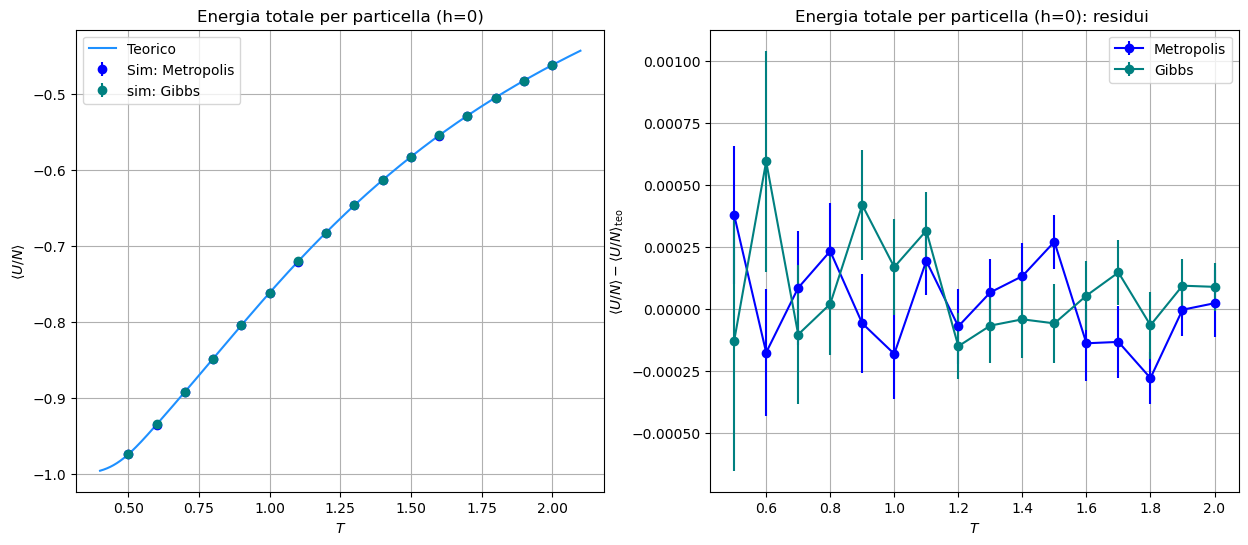

In [7]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

plot_data(axs,#vettore con gli assi dei grafici
    T_values,T, #valori temperature considerate nelle simulazioni, e per plot linea teorica
    metro_data,metro_err,gibbs_data,gibbs_err, #dati
    "total_energy", #proprietà da visualizzare
    "Energia totale per particella (h=0)", #titolo
    "U/N",#per etichetta asse y
    te#funzione teorica per confronto
    );


### Capacità termica

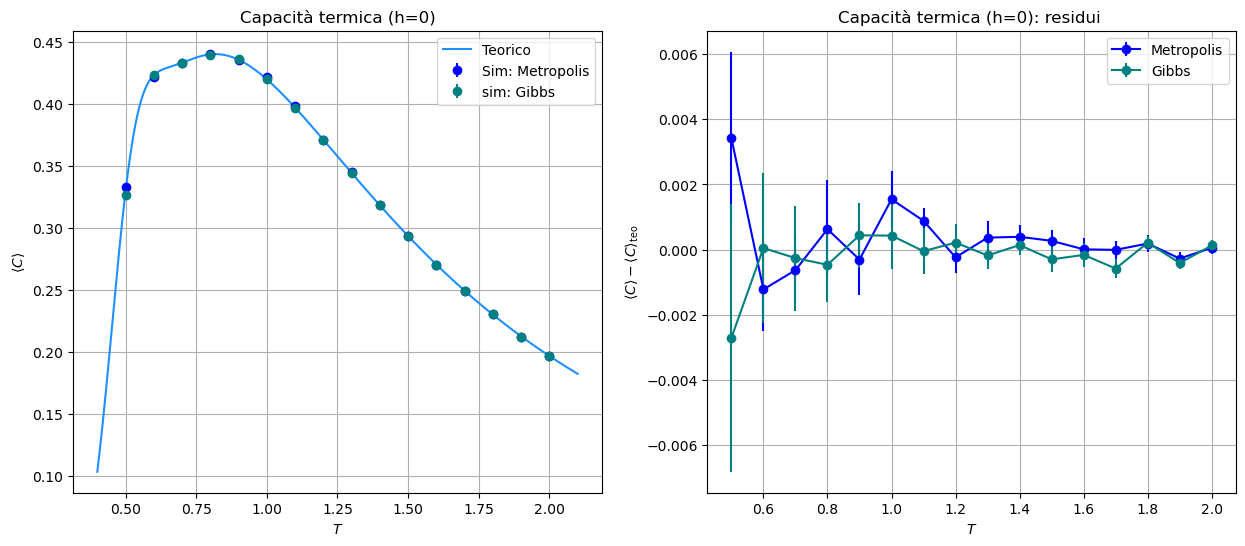

In [8]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


plot_data(axs,#vettore con gli assi per i grafici
    T_values,T, #valori temperature considerate nelle simulazioni, e per plot linea teorica
    metro_data,metro_err,gibbs_data,gibbs_err, #dati
    "specific_heat", #proprietà da visualizzare
    "Capacità termica (h=0)", #titolo
    "C",#per etichetta asse y
    heat#funzione teorica per confronto
    );

### Suscettibilità

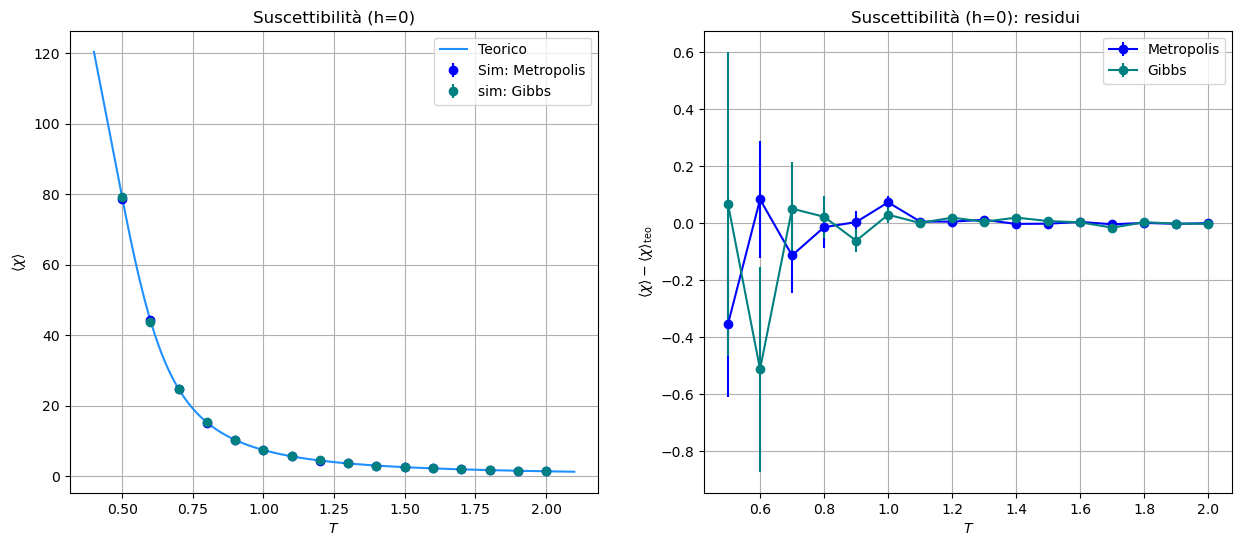

In [9]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


plot_data(axs,#vettore con gli assi per i grafici
    T_values,T, #valori temperature considerate nelle simulazioni, e per plot linea teorica
    metro_data,metro_err,gibbs_data,gibbs_err, #dati
    "susceptibility", #proprietà da visualizzare
    "Suscettibilità (h=0)", #titolo
    "\chi",#per etichetta asse y
    X#funzione teorica per confronto
    );



### Magnetizzazione

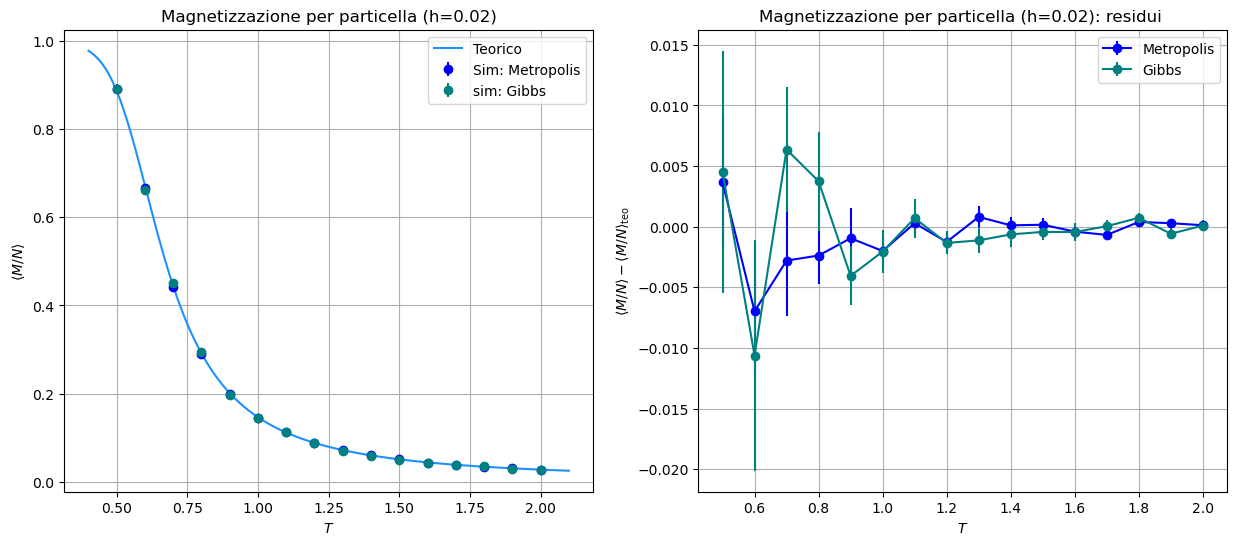

In [10]:
fig,axs=plt.subplots(1,2,figsize=[15,6])


plot_data(axs,#vettore con gli assi per i grafici
    T_values,T, #valori temperature considerate nelle simulazioni, e per plot linea teorica
    metro_data,metro_err,gibbs_data,gibbs_err, #dati
    "magnetization",#proprietà da visualizzare 
    "Magnetizzazione per particella (h=0.02)", #titolo
    "M/N",#per etichetta asse y
    M#funzione teorica per confronto
    );


C'è un discreto accordo tra le previsioni teoriche e i risultati delle simulazioni.

Nota: per eseguire le simulazioni a catena, è stato utilizzato uno script python, riportato nella cartella  `l_06_es_1`.